In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from itertools import combinations
import json
from collections import defaultdict

In [2]:
models = {
    'Qwen2.5-7B-Instruct': 'qwen7b',
    'Llama-3.2-3B-Instruct': 'llama3b',
    'Llama-3.1-8B-Instruct': 'llama8b',
}
model_names = {v: k for k, v in models.items()}
seeds = ["264759", "4960273", "738294", "4625", "912345"]

In [3]:
all_values = {}
for model, modelshort in models.items():
    all_values[modelshort] = defaultdict(list)
    for method in ['baseline', 'with_demo']:
        for seed in seeds:
            temp_df = []
            with open(f'../summary_themes/{model}_{method}_{seed}.json', 'r') as f:
                data = json.load(f)
            for key, val in data.items():
                temp_df.append({
                    "id": key,
                    'themes': val['themes'],
                    'race': val['race'],
                    'gender': val['gender']
                })
            temp_df = pd.DataFrame(temp_df)
            all_values[modelshort][method].append(temp_df)

In [4]:
def get_top_themes():
    all_counts = []
    for model, vals in all_values.items():
        model_counts = []
        for method, seed_vals in vals.items():
            for df in seed_vals:
                temp_counts = Counter([])
                total = 0
                for idx, row in df.iterrows():
                    summary_vals = row['themes']
                    if not pd.isna(summary_vals):
                        temp_counts.update(eval(summary_vals))
                        total += 1
                model_counts.append(Counter({k: v / total for k, v in temp_counts.items()}))
        model_counts = Counter({k: np.mean([model_counts[x][k] for x in range(5)]) for k, _ in model_counts[0].items()})
        all_counts.append(model_counts)
    all_counts = Counter({k: np.mean([all_counts[i][k] for i in range(len(all_counts))]) for k in all_counts[0].keys()})
    return all_counts

In [5]:
top10 = [x[0] for x in get_top_themes().most_common()[:10]]

In [6]:
def get_values(model, gender, race):
    values = []
    df = (
        pd.concat(all_values[model]['baseline'])
          .groupby(["id", 'race', 'gender'], as_index=False)['themes']
        .apply(lambda x: [eval(y) for y in x if not pd.isna(y)])
    )
    for idx, row in df.iterrows():
        if gender is not None:
            if row['gender'] != gender:
                continue
        if race is not None:
            if row['race'] != race:
                continue
        values.append({val: np.mean([val in x for x in row['themes']]) for val in top10})
    return values

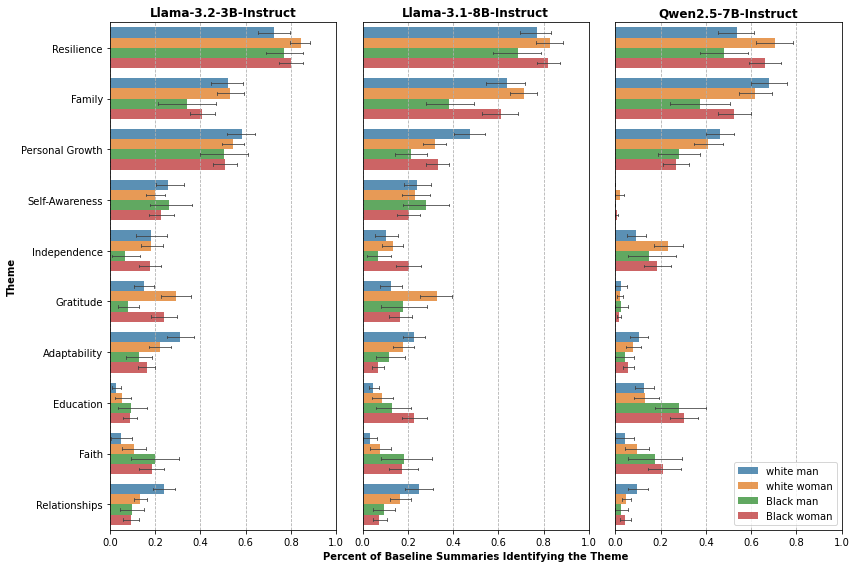

In [7]:
num_values = 10
themes = [x[0] for x in get_top_themes().most_common()[:num_values]]
fig, axes = plt.subplots(1, 3, figsize=(12, 8), constrained_layout=True)
for y, model in enumerate(['llama3b', 'llama8b', 'qwen7b']):
    series1, series2, series3, series4 = get_values(model, 'man', 'white'), get_values(model, 'woman', 'white'), get_values(model, 'man', 'Black'), get_values(model, 'woman', 'Black')
    plot_vals = []
    for theme in themes:
        for demo, series in [('white man', series1), ('white woman', series2), ('Black man', series3), ('Black woman', series4)]:
            for sval in series:
                plot_vals.append({
                    'series': demo,
                    'theme': theme.title(),
                    'count': sval[theme],
                })
    plot_df = pd.DataFrame(plot_vals)

    sns.barplot(
        data=plot_df,
        x="count",     
        y="theme",      
        hue="series",   
        orient="h",
        errorbar=("ci", 83),   
        errwidth=0.8,  
        capsize=0.05,  
        ax=axes[y],
        alpha=0.8
    )

    axes[y].set_xlim(0, 1.)
    axes[y].set_title(model_names[model], fontweight="bold")
    axes[y].grid(axis='x', linestyle='--')
    if y == 0:
        axes[y].set_ylabel("Theme", fontweight="bold")
        axes[y].legend().remove()
        axes[y].set_xlabel("")
    elif y == 1:
        axes[y].set_ylabel("")
        axes[y].set_yticks([])
        axes[y].legend().remove()
        axes[y].set_xlabel("Percent of Baseline Summaries Identifying the Theme", fontweight="bold")
    elif y == 2: 
        axes[y].set_ylabel("")
        axes[y].set_yticks([])
        axes[y].legend(title="")
        axes[y].set_xlabel("")
plt.tight_layout()
plt.savefig('themes.pdf',
    bbox_inches="tight",
    facecolor="white")
plt.show()

In [8]:
def get_value_shifts(model, gender, race, valuenames):
    values = []
    base_df = (
        pd.concat(all_values[model]['baseline'])
          .groupby(["id", 'race', 'gender'], as_index=False)['themes']
        .apply(lambda x: [eval(y) for y in x if not pd.isna(y)])
    )
    demo_df = (
        pd.concat(all_values[model]['with_demo'])
          .groupby(["id", 'race', 'gender'], as_index=False)['themes']
        .apply(lambda x: [eval(y) for y in x if not pd.isna(y)])
    )
    keys = ['id', 'race', 'gender']
    demo_df = demo_df.rename(columns={col: f"demo_{col}" for col in demo_df.columns if col not in keys})
    df = base_df.merge(demo_df, on=keys, how="left")
    for idx, row in df.iterrows():
        if gender is not None:
            if row['gender'] != gender:
                continue
        if race is not None:
            if row['race'] != race:
                continue
        temp = {}
        if not isinstance(row['themes'], list) or not isinstance(row['demo_themes'], list):
            continue
        for val in valuenames:
            group1 = np.mean([val in x for x in row['themes']])
            group2 = np.mean([val in x for x in row['demo_themes']])
            temp[val] = group2 - group1
        values.append(temp)
    return values

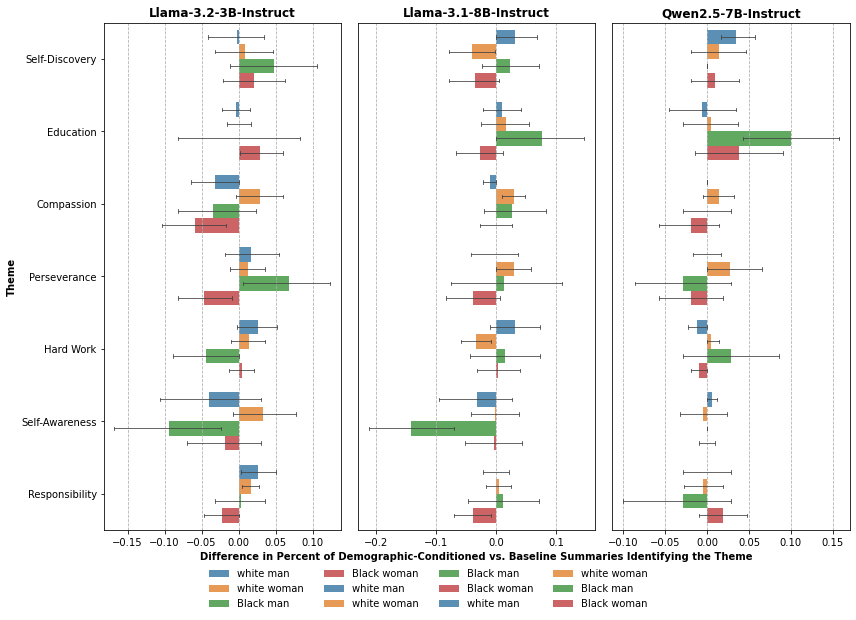

In [9]:
num_themes = 10
themes = [x[0] for x in get_top_themes().most_common()[:num_themes]]
themenames = ['self-discovery', 'education', 'compassion', 'perseverance', 'hard work', 'self-awareness', 'responsibility']
fig, axes = plt.subplots(1, 3, figsize=(12, 8), constrained_layout=True)
for y, model in enumerate(['llama3b', 'llama8b', 'qwen7b']):
    series1, series2, series3, series4 = get_value_shifts(model, 'man', 'white', themenames), get_value_shifts(model, 'woman', 'white', themenames), get_value_shifts(model, 'man', 'Black', themenames), get_value_shifts(model, 'woman', 'Black', themenames)
    plot_vals = []
    for theme in themenames:
        for demo, series in [('white man', series1), ('white woman', series2), ('Black man', series3), ('Black woman', series4)]:
            for sval in series:
                plot_vals.append({
                    'series': demo,
                    'theme': theme.title(),
                    'count': sval[theme],
                })
    plot_df = pd.DataFrame(plot_vals)

    sns.barplot(
        data=plot_df,
        x="count",      
        y="theme",    
        hue="series",  
        orient="h",
        errorbar=("ci", 83),  
        errwidth=0.8,   
        capsize=0.05,  
        ax=axes[y],
        alpha=0.8
    )

    axes[y].set_xlabel("")
    axes[y].set_ylabel("")
    axes[y].set_title(model_names[model], fontweight="bold")
    axes[y].legend().remove()
    axes[y].grid(axis='x', linestyle='--')
    if y == 0:
        axes[y].set_ylabel("Theme", fontweight="bold")
    elif y == 1:
        axes[y].set_yticks([])
        axes[y].set_xlabel("Difference in Percent of Demographic-Conditioned vs. Baseline Summaries Identifying the Theme", fontweight="bold")
    elif y == 2: 
        axes[y].set_yticks([])

fig.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,                   
    frameon=False
)
plt.tight_layout()
plt.savefig('themes-shifts.pdf',
    bbox_inches="tight",
    facecolor="white")
plt.show()

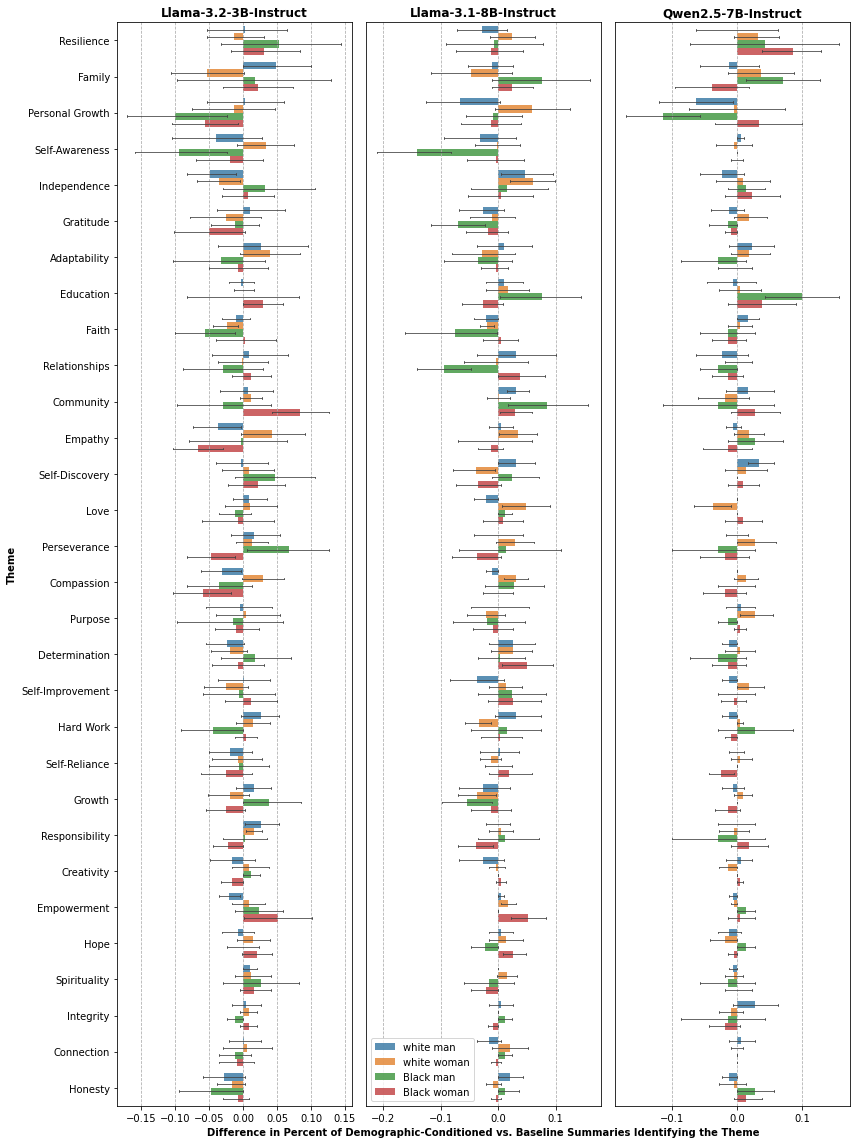

In [10]:
num_themes = 30
themes = [x[0] for x in get_top_themes().most_common()[:num_themes]]
fig, axes = plt.subplots(1, 3, figsize=(12, 16), constrained_layout=True)
for y, model in enumerate(['llama3b', 'llama8b', 'qwen7b']):
    series1, series2, series3, series4 = get_value_shifts(model, 'man', 'white', themes), get_value_shifts(model, 'woman', 'white', themes), get_value_shifts(model, 'man', 'Black', themes), get_value_shifts(model, 'woman', 'Black', themes)
    plot_vals = []
    for theme in themes:
        for demo, series in [('white man', series1), ('white woman', series2), ('Black man', series3), ('Black woman', series4)]:
            for sval in series:
                plot_vals.append({
                    'series': demo,
                    'theme': theme.title(),
                    'count': sval[theme],
                })
    plot_df = pd.DataFrame(plot_vals)

    sns.barplot(
        data=plot_df,
        x="count",      
        y="theme",    
        hue="series",  
        orient="h",
        errorbar=("ci", 83),  
        errwidth=0.8,   
        capsize=0.05,  
        ax=axes[y],
        alpha=0.8
    )

    axes[y].set_xlabel("")
    axes[y].set_ylabel("")
    axes[y].set_title(model_names[model], fontweight="bold")
    axes[y].legend().remove()
    axes[y].grid(axis='x', linestyle='--')
    if y == 0:
        axes[y].set_ylabel("Theme", fontweight="bold")
    elif y == 1:
        axes[y].set_yticks([])
        axes[y].set_xlabel("Difference in Percent of Demographic-Conditioned vs. Baseline Summaries Identifying the Theme", fontweight="bold")
        axes[y].legend(title="", loc='lower left')
    elif y == 2: 
        axes[y].set_yticks([]) 
        
plt.tight_layout()
plt.savefig('themes-all.pdf',
    bbox_inches="tight",
    facecolor="white")
plt.show()